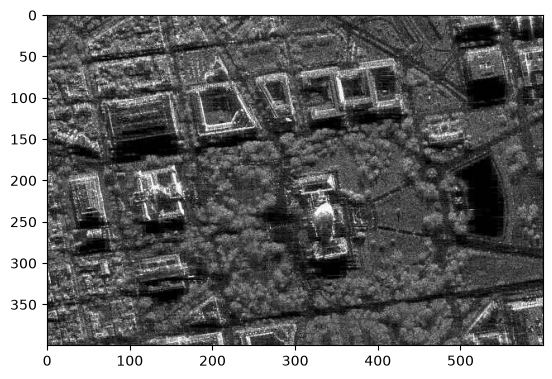

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


image_gray = cv2.imread('sar_1_gray.jpg',cv2.IMREAD_GRAYSCALE)
plt.imshow(image_gray,cmap='gray')
plt.show()


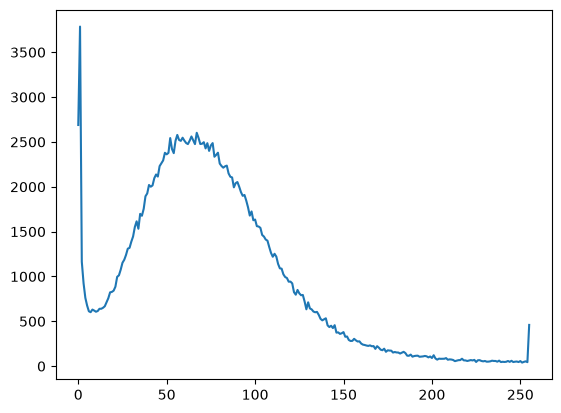

In [8]:
hist = cv2.calcHist([image_gray],[0],None,[256],(0,256))
plt.plot(hist)
plt.show()


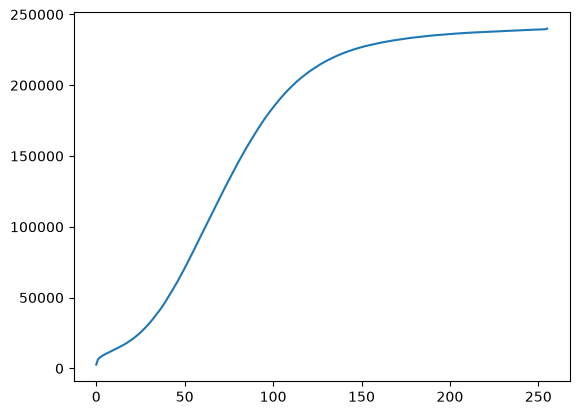

In [10]:
hist_cum = hist.cumsum()
plt.plot(hist_cum)
plt.show()

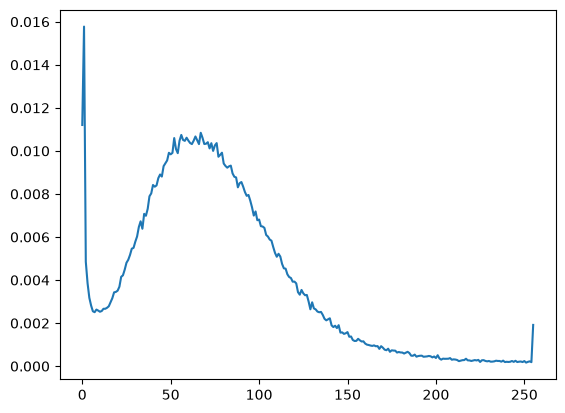

In [12]:
hist_norm = hist/(image_gray.shape[0]*image_gray.shape[1])
plt.plot(hist_norm)
plt.show()

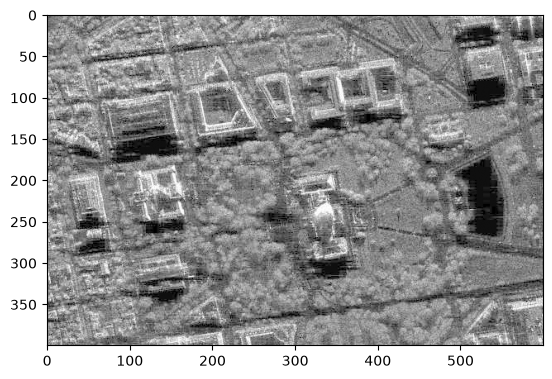

In [15]:
def correction(image,gamma):
    img_norm = image /255.0
    corrected = np.power(img_norm, gamma)
    return (corrected *255).astype(np.uint8)

gamma_low = correction(image_gray, 0.5)
plt.imshow(gamma_low,cmap='gray')
plt.show()


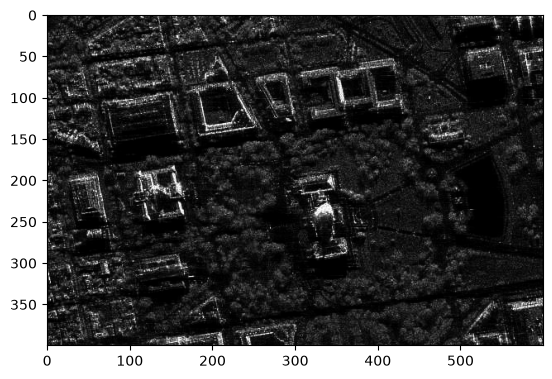

In [17]:
gamma_high = correction(image_gray,2)
plt.imshow(gamma_high, cmap = 'gray')
plt.show()

In [19]:
from skimage.metrics import structural_similarity,mean_squared_error

mse_low = mean_squared_error(image_gray, gamma_low)
mse_high = mean_squared_error(image_gray,gamma_high)

ssim_low, dif_low = structural_similarity(image_gray, gamma_low, full = True)
ssim_high,dif_high = structural_similarity(image_gray,gamma_high,full = True)

print("gamma = 0,5  MSE: ", mse_low, " SSIM: ", ssim_low)
print("gamma = 2  MSE: ", mse_high, " SSIM: ", ssim_high)



gamma = 0,5  MSE:  3250.429145833333  SSIM:  0.7875008686792752
gamma = 2  MSE:  2383.7636375  SSIM:  0.5270459922820343


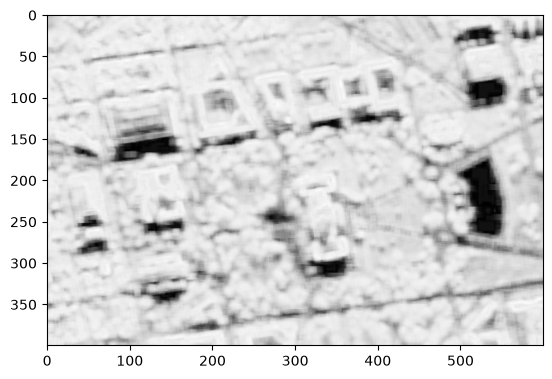

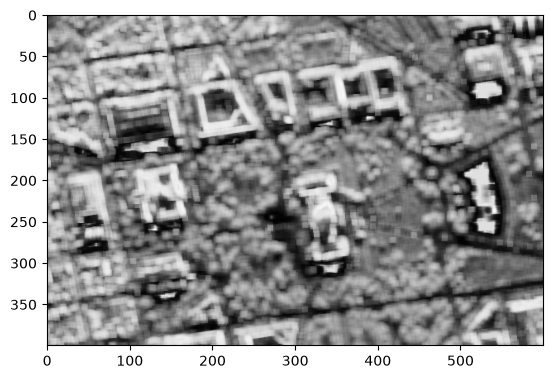

In [20]:
plt.imshow((dif_low * 255).astype('uint8'), cmap='gray')
plt.show()

plt.imshow((dif_high * 255).astype('uint8'), cmap='gray')
plt.show()


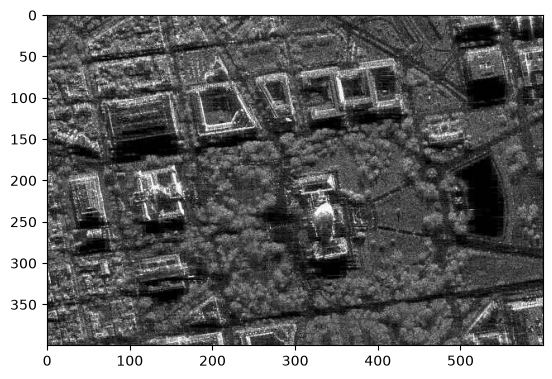

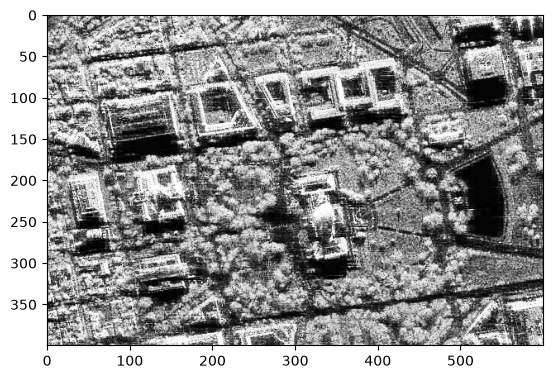

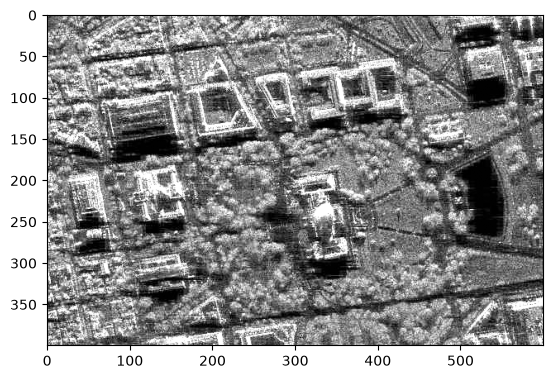

Оригинал:    mean = 74.94157083333333  std = 43.658465466227916
eq_gray:     mean = 127.02563333333333  std = 74.26964841889017
Corrected:   mean = 123.1181375  std = 65.3025763098039


In [21]:
eq_gray = cv2.equalizeHist(image_gray)

E_t = image_gray.mean()
D_t = image_gray.std()
E_s = eq_gray.mean()
D_s = eq_gray.std()

corrected = E_s + (image_gray.astype(np.float32) - E_t) * (D_s / D_t)
corrected = np.clip(corrected, 0, 255).astype(np.uint8)

plt.imshow(image_gray, cmap='gray')
plt.show()

plt.imshow(eq_gray, cmap='gray')
plt.show()

plt.imshow(corrected, cmap='gray')
plt.show()

print("Оригинал:    mean =", E_t, " std =", D_t)
print("eq_gray:     mean =", E_s, " std =", D_s)
print("Corrected:   mean =", corrected.mean(), " std =", corrected.std())

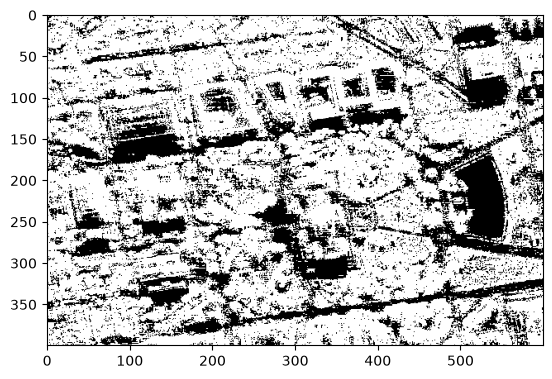

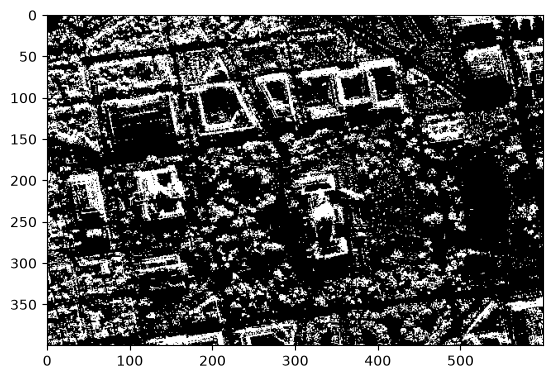

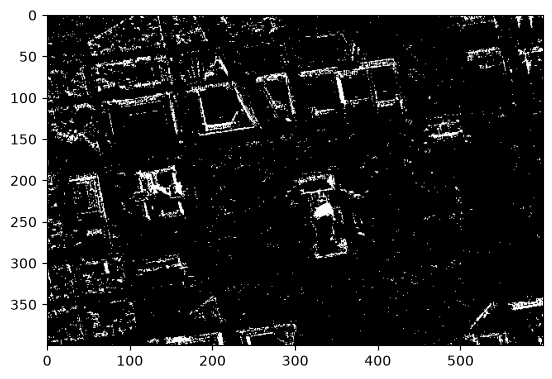

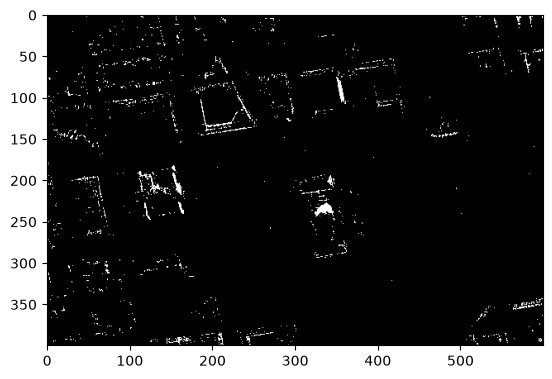

In [22]:
_, thresh1 = cv2.threshold(image_gray, 50, 255, cv2.THRESH_BINARY)
plt.imshow(thresh1, cmap='gray')
plt.show()

_, thresh2 = cv2.threshold(image_gray, 100, 255, cv2.THRESH_BINARY)
plt.imshow(thresh2, cmap='gray')
plt.show()

_, thresh3 = cv2.threshold(image_gray, 150, 255, cv2.THRESH_BINARY)
plt.imshow(thresh3, cmap='gray')
plt.show()

_, thresh4 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_BINARY)
plt.imshow(thresh4, cmap='gray')
plt.show()